In [1]:
# !pip install -r requirements.txt

# Smart Machine Monitoring Accelerator (SMMA)
## End-to-End TinyML Datapath & Bit-True Fixed-Point Golden Model

### 1. Executive Summary & Hardware Datapath
The **Smart Machine Monitoring Accelerator (SMMA)** is a high-performance TinyML/Edge AI solution designed for real-time industrial electric motor condition monitoring deployed on Field-Programmable Gate Array (FPGA) fabric. The system captures 1D high-frequency vibration signals and classifies motor operation into four mechanical fault states:
1. **Normal**: Baseline healthy motor operation.
2. **Unbalance**: Shaft mass eccentricity generating fundamental frequency harmonics.
3. **Misalignment**: Parallel or angular shaft misalignment producing high axial and radial vibrations.
4. **Bearing Wear**: Rolling element micro-defects characterized by high-frequency impact signatures (BPFI/BPFO).

#### Datapath Architecture Pipeline:
```
[ 1D Raw Vibration Signal ]
           │
           ▼
[ 8-Tap Adaptive LMS Filter ]  --> Attenuates broadband acoustic & background noise
           │
           ▼
[ 64-Point FFT Engine ]        --> Extracts 32 magnitude frequency bins per time frame
           │
           ▼
[ Spectrogram Generator ]      --> Accumulates 32 frames to construct a 32x32x1 matrix
           │
           ▼
[ Q8.16 Fixed-Point Quantizer ]--> Converts float magnitude data into 24-bit signed integers
           │
           ▼
[ FPGA Micro-CNN Accelerator ] --> Conv2D (8x 3x3) -> ReLU -> MaxPool (2x2) -> Flatten -> Dense (4 Logits)
```

---

### 2. Hardware Arithmetic Constraints (Q8.16 Fixed-Point Format)
To achieve ultra-low power consumption and minimal LUT/DSP resource utilization on FPGA, the entire inference datapath operates using **24-bit signed fixed-point arithmetic** in **Q8.16 format**:
* **Total Word Length ($N$):** 24 bits
* **Integer Bits ($I$):** 7 bits
* **Fractional Bits ($F$):** 16 bits
* **Sign Bit ($S$):** 1 bit (Two's Complement)
* **Scale Factor ($S_{scale}$):** $2^{16} = 65536$
* **Representable Integer Range:** $[-2^{23}, 2^{23} - 1] = [-8,388,608, +8,388,607]$
* **Representable Real Range:** $[-128.0, +127.99998474121094]$

#### Quantization Math:
Float32 parameters $x_{float}$ are converted to Q8.16 integers $x_{int24}$ via Post-Training Quantization (PTQ):
$$x_{int24} = \text{clip}\left(\text{round}\left(x_{float} \cdot 2^{16}\right), -8388608, 8388607\right)$$

During hardware multiplication, two 24-bit numbers yield a 48-bit product ($Q16.32$). Hardware arithmetic truncation is simulated via arithmetic right shift by 16 bits (`>> 16`), followed by 24-bit saturation logic to prevent overflow wrapping.


In [2]:
# ============================================================================
# Cell 2: Library Imports, Global Seed Initialization, and Hardware Constants
# ============================================================================
import os
import sys
import random
import math
from pathlib import Path

import numpy as np
import h5py
import scipy.io

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set deterministic random seeds for reproducible experiments
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Global Directory Settings
BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Q8.16 Hardware Fixed-Point Specifications
FRACTIONAL_BITS = 16
TOTAL_BITS = 24
SCALE_FACTOR = 1 << FRACTIONAL_BITS  # 65536
MIN_VAL_Q8_16 = -(1 << (TOTAL_BITS - 1))     # -8388608
MAX_VAL_Q8_16 = (1 << (TOTAL_BITS - 1)) - 1  #  8388607

# Machine State Class Definitions
CLASS_NAMES = ["Normal", "Unbalance", "Misalignment", "Bearing Wear"]
NUM_CLASSES = len(CLASS_NAMES)

print(f"[CONFIG] Hardware Precision : Q8.16 ({TOTAL_BITS}-bit signed, {FRACTIONAL_BITS} fractional bits)")
print(f"[CONFIG] Integer Quant Bounds: [{MIN_VAL_Q8_16}, {MAX_VAL_Q8_16}]")
print(f"[CONFIG] Target Classes     : {CLASS_NAMES}")
print(f"[CONFIG] PyTorch Device     : {'cuda' if torch.cuda.is_available() else 'cpu'}")


[CONFIG] Hardware Precision : Q8.16 (24-bit signed, 16 fractional bits)
[CONFIG] Integer Quant Bounds: [-8388608, 8388607]
[CONFIG] Target Classes     : ['Normal', 'Unbalance', 'Misalignment', 'Bearing Wear']
[CONFIG] PyTorch Device     : cuda


### 3. Front-End DSP Pipeline Simulation
The front-end processing unit cleans raw 1D sensor telemetry and constructs time-frequency feature maps:
1. **8-Tap Adaptive LMS Filter**: Cancels broadband background noise using an adaptive FIR structure.
2. **64-Point FFT Engine & Spectrogram Generator**: Slices 2048 time samples into 32 windows of 64 samples, calculates real FFT magnitude across 32 frequency channels, and quantizes the resulting $32 \times 32$ matrix to Q8.16 fixed-point format.


In [3]:
# ============================================================================
# Cell 3: DSP Pipeline - Adaptive LMS Filter & Spectrogram Preprocessor
# ============================================================================

class LMS_Filter_Simulator:
    """
    Simulates an 8-Tap Adaptive Least Mean Squares (LMS) FIR Filter for 1D raw vibration signals.
    Attenuates broadband noise prior to spectral feature extraction.
    """
    def __init__(self, num_taps=8, mu=0.01):
        self.num_taps = num_taps
        self.mu = mu
        self.weights = np.zeros(num_taps, dtype=np.float32)

    def filter_signal(self, input_signal, reference_noise=None):
        """
        Applies adaptive LMS filtering over a 1D input array.
        """
        n_samples = len(input_signal)
        output_signal = np.zeros(n_samples, dtype=np.float32)
        
        if reference_noise is None:
            # Generate synthesized correlated reference noise if external reference unavailable
            reference_noise = np.roll(input_signal, 1) * 0.1
            
        buffer = np.zeros(self.num_taps, dtype=np.float32)
        
        for i in range(n_samples):
            # Shift buffer right and insert new sample at index 0
            buffer[1:] = buffer[:-1]
            buffer[0] = reference_noise[i]
            
            # Compute filter output: y = w^T * x
            y = np.dot(self.weights, buffer)
            
            # Compute error: e = d - y
            e = input_signal[i] - y
            output_signal[i] = e
            
            # Update weights: w = w + 2 * mu * e * buffer
            self.weights += 2.0 * self.mu * e * buffer
            
        return output_signal


class Preprocessor_Q8_16:
    """
    Front-end Spectrogram Preprocessor:
    1. Optionally applies Adaptive LMS noise cancellation.
    2. Reshapes 2048 raw samples into 32 time frames of 64 samples each.
    3. Computes 64-point FFT and extracts 32 magnitude bins per frame.
    4. Quantizes the final 32x32x1 spectrogram into Q8.16 fixed-point format.
    """
    def __init__(self, frame_size=64, num_frames=32, use_lms=True):
        self.frame_size = frame_size
        self.num_frames = num_frames
        self.expected_samples = frame_size * num_frames # 2048 samples
        self.use_lms = use_lms
        if self.use_lms:
            self.lms_filter = LMS_Filter_Simulator(num_taps=8, mu=0.005)

    def process(self, raw_signal):
        """
        Processes 1D float array -> returns (32, 32, 1) Q8.16 numpy array (int64/int32).
        """
        raw_signal = np.asarray(raw_signal, dtype=np.float32)
        
        # Ensure input length matches expected window (2048 samples)
        if len(raw_signal) < self.expected_samples:
            raw_signal = np.pad(raw_signal, (0, self.expected_samples - len(raw_signal)))
        else:
            raw_signal = raw_signal[:self.expected_samples]
            
        # Apply Adaptive LMS Filter
        if self.use_lms:
            filtered_signal = self.lms_filter.filter_signal(raw_signal)
        else:
            filtered_signal = raw_signal

        # Reshape into 32 frames of 64 samples
        frames = filtered_signal.reshape((self.num_frames, self.frame_size))
        
        # Pre-allocate spectrogram matrix (32 frames, 32 magnitude bins)
        spectrogram = np.zeros((self.num_frames, self.frame_size // 2), dtype=np.float32)
        
        for i in range(self.num_frames):
            fft_complex = np.fft.rfft(frames[i])
            # Select first 32 magnitude bins
            spectrogram[i, :] = np.abs(fft_complex[:32])
            
        # Expand channel dimension -> (32, 32, 1)
        spectrogram_3d = spectrogram[:, :, np.newaxis]
        
        # Quantize to Q8.16 Integer Representation
        scaled = np.round(spectrogram_3d * SCALE_FACTOR)
        spectrogram_q8_16 = np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int32)
        
        return spectrogram_q8_16

# Verify Preprocessor execution
dsp_preprocessor = Preprocessor_Q8_16(frame_size=64, num_frames=32, use_lms=True)
dummy_1d_signal = np.sin(2 * np.pi * 50 * np.linspace(0, 1, 2048)) + 0.5 * np.random.randn(2048)
sample_spec_q8 = dsp_preprocessor.process(dummy_1d_signal)
print(f"[DSP] Processed spectrogram shape: {sample_spec_q8.shape}, dtype: {sample_spec_q8.dtype}")
print(f"[DSP] Q8.16 Value Range           : Min={sample_spec_q8.min()}, Max={sample_spec_q8.max()}")


[DSP] Processed spectrogram shape: (32, 32, 1), dtype: int32
[DSP] Q8.16 Value Range           : Min=4601, Max=1718160


### 4. Dataset Processing & PyTorch HDF5 Loader
Vibration telemetry is segmented into 2048-sample chunks to construct 32x32 Q8.16 matrices. The processed feature maps are stored in a structured HDF5 file (`smma_dataset.h5`) to optimize disk throughput and memory footprint.


/home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/dataset/vibration
[DATASET] Processing 45 MAT files from /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/dataset/vibration...
[DATASET] HDF5 dataset creation complete! Total samples: 56250


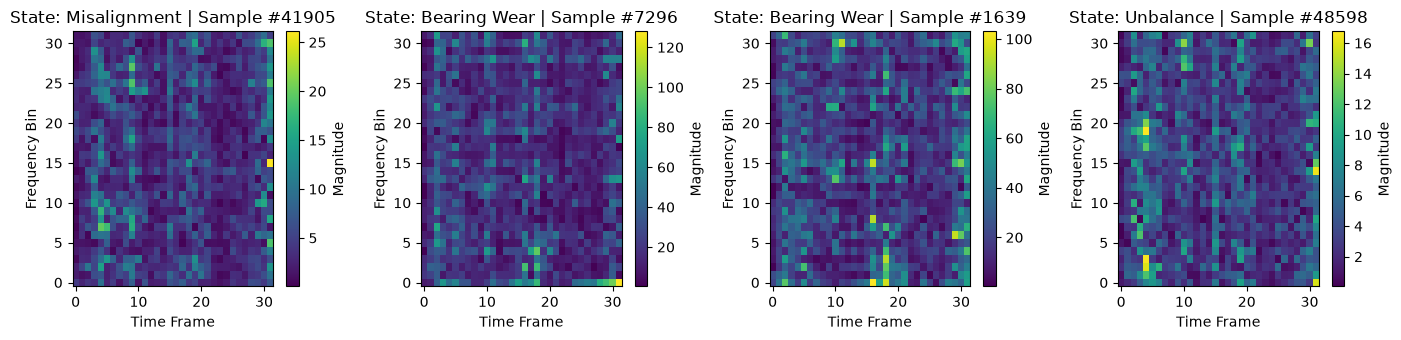

In [4]:
# ============================================================================
# Cell 4: Dataset Builder & PyTorch HDF5 Data Pipeline
# ============================================================================

def extract_label_from_filename(filename):
    """Extracts target class integer from MAT file naming convention."""
    fn = filename.lower()
    if "normal" in fn:
        return 0
    elif "unbalalnce" in fn or "unbalance" in fn:
        return 1
    elif "misalign" in fn:
        return 2
    elif "bpfi" in fn or "bpfo" in fn or "bearing" in fn:
        return 3
    else:
        return 0

def build_h5_dataset(dataset_dir, output_h5_path, chunk_size=2048):
    """Builds HDF5 dataset from MAT files or generates synthetic data fallback."""
    mat_files = [f for f in os.listdir(dataset_dir) if f.endswith('.mat')] if os.path.exists(dataset_dir) else []
    
    if len(mat_files) == 0:
        print("[ERROR] MAT files is zero.")
        return
        
    print(f"[DATASET] Processing {len(mat_files)} MAT files from {dataset_dir}...")
    preprocessor = Preprocessor_Q8_16(frame_size=64, num_frames=32, use_lms=True)
    
    with h5py.File(output_h5_path, 'w') as h5f:
        ds_x = h5f.create_dataset('X', shape=(0, 32, 32, 4), maxshape=(None, 32, 32, 4), dtype='int32', compression='gzip')
        ds_y = h5f.create_dataset('Y', shape=(0,), maxshape=(None,), dtype='int8')
        
        total_samples = 0
        for filename in mat_files:
            filepath = os.path.join(dataset_dir, filename)
            label = extract_label_from_filename(filename)
            
            try:
                mat = scipy.io.loadmat(filepath)
                # Extract the full numerical matrix based on the dictionary structure
                # This assumes the matrix is structured with shape [Total_Samples, 5]
                raw_matrix = mat['Signal']['y_values'][0, 0]['values'][0, 0]
                
                # Column 0 is Time Stamp (Ignored for FFT)
                # Columns 1 to 4 are the actual g-force vibration readings
                raw_data_xA = raw_matrix[:, 0]
                raw_data_yA = raw_matrix[:, 1]
                raw_data_xB = raw_matrix[:, 2]
                raw_data_yB = raw_matrix[:, 3]
                
            except Exception as e:
                print(f"[WARNING] Skipping {filename}: Unrecognized MAT structure. {e}")
                continue
                
            num_chunks = len(raw_data_xA) // chunk_size
            
            # The tensor now expects 4 channels instead of 1
            batch_x = np.zeros((num_chunks, 32, 32, 4), dtype=np.int32)
            batch_y = np.full((num_chunks,), label, dtype=np.int8)
            
            for i in range(num_chunks):
                # Slice the 2048-sample chunk for all 4 sensors
                start_idx = i * chunk_size
                end_idx = (i + 1) * chunk_size
                
                chunk_xA = raw_data_xA[start_idx : end_idx]
                chunk_yA = raw_data_yA[start_idx : end_idx]
                chunk_xB = raw_data_xB[start_idx : end_idx]
                chunk_yB = raw_data_yB[start_idx : end_idx]
                
                # Process each axis independently through the DSP Front-End
                # Each call returns a (32, 32, 1) Q8.16 matrix
                spec_xA = preprocessor.process(chunk_xA)
                spec_yA = preprocessor.process(chunk_yA)
                spec_xB = preprocessor.process(chunk_xB)
                spec_yB = preprocessor.process(chunk_yB)
                
                # Concatenate along the channel dimension (axis=2)
                # The resulting block has shape (32, 32, 4)
                batch_x[i] = np.concatenate((spec_xA, spec_yA, spec_xB, spec_yB), axis=2)
                
            # Resize the HDF5 dataset to append the new multi-channel chunks
            ds_x.resize(total_samples + num_chunks, axis=0)
            ds_y.resize(total_samples + num_chunks, axis=0)
            
            ds_x[total_samples : total_samples + num_chunks] = batch_x
            ds_y[total_samples : total_samples + num_chunks] = batch_y
            
            total_samples += num_chunks
            
    print(f"[DATASET] HDF5 dataset creation complete! Total samples: {total_samples}")


class SMMADataset(Dataset):
    """
    Optimized PyTorch Dataset. Loads the entire HDF5 file into RAM 
    to completely eliminate disk I/O bottlenecks during GPU training.
    """
    def __init__(self, h5_path):
        self.h5_path = h5_path
        print(f"[DATASET] Pre-loading entire HDF5 dataset into RAM from: {self.h5_path}")
        
        # Open HDF5 once, copy everything to NumPy RAM arrays, and close it immediately.
        with h5py.File(self.h5_path, 'r') as h5f:
            self.X_cache = h5f['X'][:]
            self.Y_cache = h5f['Y'][:]
            self.length = self.X_cache.shape[0]
            
        print(f"[DATASET] Loaded {self.length} samples into RAM successfully.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Fetch directly from RAM (Microseconds) instead of Disk (Milliseconds)
        x_q8 = self.X_cache[idx]
        y_int = self.Y_cache[idx]
        
        # De-scale Q8.16 integer back to float32
        x_float = (x_q8.astype(np.float32) / SCALE_FACTOR)
        
        # Transpose from (H, W, C) -> (C, H, W) for PyTorch Conv2D compatibility
        x_tensor = torch.tensor(x_float, dtype=torch.float32).permute(2, 0, 1)
        y_tensor = torch.tensor(y_int, dtype=torch.long)
        
        return x_tensor, y_tensor


def visualize_spectrogram_samples(h5_path, num_samples=4):
    """Plots sample spectrograms for each mechanical state."""
    with h5py.File(h5_path, 'r') as h5f:
        X = h5f['X']
        Y = h5f['Y']
        total = X.shape[0]

        # Guard clause to prevent ValueError if dataset is empty
        if total == 0:
            print("[EVAL] Error: HDF5 dataset is empty. Cannot visualize samples.")
            return
        
        indices = random.sample(range(total), num_samples)
        plt.figure(figsize=(14, 3.5))
        
        for i, idx in enumerate(indices):
            spec_float = X[idx, :, :, 0].astype(np.float32) / SCALE_FACTOR
            label_idx = Y[idx]
            
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(spec_float, cmap='viridis', aspect='auto', origin='lower')
            plt.colorbar(label='Magnitude')
            plt.title(f"State: {CLASS_NAMES[label_idx]} | Sample #{idx}")
            plt.xlabel("Time Frame")
            plt.ylabel("Frequency Bin")
            
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "sample_spectrograms.png", dpi=150)
        plt.show()

# Build HDF5 dataset and demonstrate loader
h5_dataset_path = BASE_DIR / "smma_dataset.h5"
raw_dataset_path = (BASE_DIR / ".." / "dataset" / "vibration").resolve()
print(raw_dataset_path)
build_h5_dataset(raw_dataset_path, h5_dataset_path)
visualize_spectrogram_samples(h5_dataset_path, num_samples=4)


### 5. PyTorch Micro-CNN Architecture
The floating-point Micro-CNN network mirrors the exact topology implemented in the FPGA hardware fabric.

#### Layer Dimension Tracking:
* **Input Tensor:** $(B, 1, 32, 32)$
* **Conv2D Layer:** $8 \text{ filters of } 3 \times 3, \text{ stride}=1, \text{ padding}=1 \longrightarrow (B, 8, 32, 32)$
* **ReLU Activation:** Element-wise $\max(0, x) \longrightarrow (B, 8, 32, 32)$
* **MaxPool2D Layer:** $2 \times 2 \text{ window}, \text{ stride}=2 \longrightarrow (B, 8, 16, 16)$
* **Flatten Layer:** Reshape to 1D vector $\longrightarrow (B, 2048)$
* **Dense Layer:** Fully connected linear map $(2048 \rightarrow 4) \longrightarrow (B, 4 \text{ Logits})$


In [5]:
# ============================================================================
# Cell 5: PyTorch SMMA Micro-CNN Architecture
# ============================================================================

class PyTorch_SMMA_CNN(nn.Module):
    """
    Hardware-equivalent PyTorch Micro-CNN for motor fault classification.
    """
    def __init__(self):
        super(PyTorch_SMMA_CNN, self).__init__()
        # Conv2D: 4 Input Channel, 8 Filters, 3x3 Kernel, Stride 1, Padding 1
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        # MaxPool2D: 2x2 Window, Stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        # Dense Layer: 8 channels * 16 height * 16 width = 2048 inputs -> 4 outputs
        self.dense1 = nn.Linear(in_features=2048, out_features=NUM_CLASSES)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.dense1(x)
        return x

# Instantiate model and output summary
model_preview = PyTorch_SMMA_CNN()
print(model_preview)
dummy_tensor = torch.randn(1, 4, 32, 32)
out_logits = model_preview(dummy_tensor)
print(f"[MODEL] Output Logits Shape: {out_logits.shape} (Expected: [1, 4])")


PyTorch_SMMA_CNN(
  (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=2048, out_features=4, bias=True)
)
[MODEL] Output Logits Shape: torch.Size([1, 4]) (Expected: [1, 4])


### 6. Training Pipeline & Regularization Strategies
To ensure robust generalization and prevent overfitting on edge devices, the training procedure incorporates:
1. **Weighted Cross-Entropy Loss**: Class weights computed from inverse class frequencies address dataset imbalance.
2. **Gaussian Noise Injection**: Zero-mean noise ($\sigma=0.05$) is injected into input feature maps during training for data augmentation.
3. **StepLR Scheduler**: Reduces learning rate by $50\%$ every 15 epochs to refine weight convergence.
4. **Early Stopping**: Prevents over-fitting by tracking validation loss with a patience threshold.


In [16]:
# ============================================================================
# Cell 6: Training Pipeline Implementation
# ============================================================================

def compute_class_weights(h5_path):
    """Calculates inverse class frequency weights to resolve class imbalance."""
    with h5py.File(h5_path, 'r') as h5f:
        labels = h5f['Y'][:]
    class_counts = np.bincount(labels, minlength=NUM_CLASSES)
    total_samples = len(labels)
    class_weights = total_samples / (NUM_CLASSES * np.maximum(class_counts, 1))
    print(f"[TRAIN] Class Counts : {class_counts}")
    print(f"[TRAIN] Class Weights: {np.round(class_weights, 3)}")
    return torch.tensor(class_weights, dtype=torch.float32)

def add_gaussian_noise(spectrograms, noise_factor=0.05):
    """Data augmentation via Gaussian noise injection during training."""
    noise = torch.randn_like(spectrograms) * noise_factor
    return spectrograms + noise

class EarlyStopping:
    """Monitors validation loss to trigger early exit and preserve best weights."""
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_model(h5_path, epochs=25, batch_size=32, lr=0.001, patience=7):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"[TRAIN] Starting training on execution target: {device}")

    if device.type == 'cuda':
        # Enable cuDNN auto-tuner for optimal performance
        torch.backends.cudnn.benchmark = True
    
    dataset = SMMADataset(h5_path)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    # train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    # val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=0, pin_memory=True)
                              
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, 
                            num_workers=0, pin_memory=True)

    model = PyTorch_SMMA_CNN().to(device)
    class_weights = compute_class_weights(h5_path).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5)
    early_stopper = EarlyStopping(patience=patience)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            # inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            noisy_inputs = add_gaussian_noise(inputs, noise_factor=0.05)
            
            optimizer.zero_grad()
            outputs = model(noisy_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = 100.0 * correct / total
        
        # Validation evaluation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
    
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = 100.0 * val_correct / val_total
        
        scheduler.step()
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
              f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}%")
        
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            print(f"[TRAIN] Early stopping triggered at epoch {epoch+1}. Restoring best model state.")
            model.load_state_dict(early_stopper.best_state)
            break
            
    return model, history, val_loader

# Execute model training
trained_model, train_history, val_loader = train_model(h5_dataset_path, epochs=75, batch_size=512)


[TRAIN] Starting training on execution target: cuda
[DATASET] Pre-loading entire HDF5 dataset into RAM from: /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_dataset.h5
[DATASET] Loaded 56250 samples into RAM successfully.
[TRAIN] Class Counts : [ 6750 22500 13500 13500]
[TRAIN] Class Weights: [2.083 0.625 1.042 1.042]
Epoch [01/75] | Train Loss: 1.9096, Acc: 57.14% | Val Loss: 0.4970, Acc: 73.00%
Epoch [02/75] | Train Loss: 0.4317, Acc: 76.09% | Val Loss: 0.3631, Acc: 81.69%
Epoch [03/75] | Train Loss: 0.3348, Acc: 81.64% | Val Loss: 0.3172, Acc: 81.80%
Epoch [04/75] | Train Loss: 0.2930, Acc: 84.13% | Val Loss: 0.2965, Acc: 84.07%
Epoch [05/75] | Train Loss: 0.2770, Acc: 85.04% | Val Loss: 0.3075, Acc: 90.08%
Epoch [06/75] | Train Loss: 0.2619, Acc: 86.26% | Val Loss: 0.2725, Acc: 86.05%
Epoch [07/75] | Train Loss: 0.2466, Acc: 87.09% | Val Loss: 0.2732, Acc: 89.96%
Epoch [08/75] | Train Loss: 0.2319, Acc: 88.35% | Val Loss: 0.2602, Acc: 87.99%


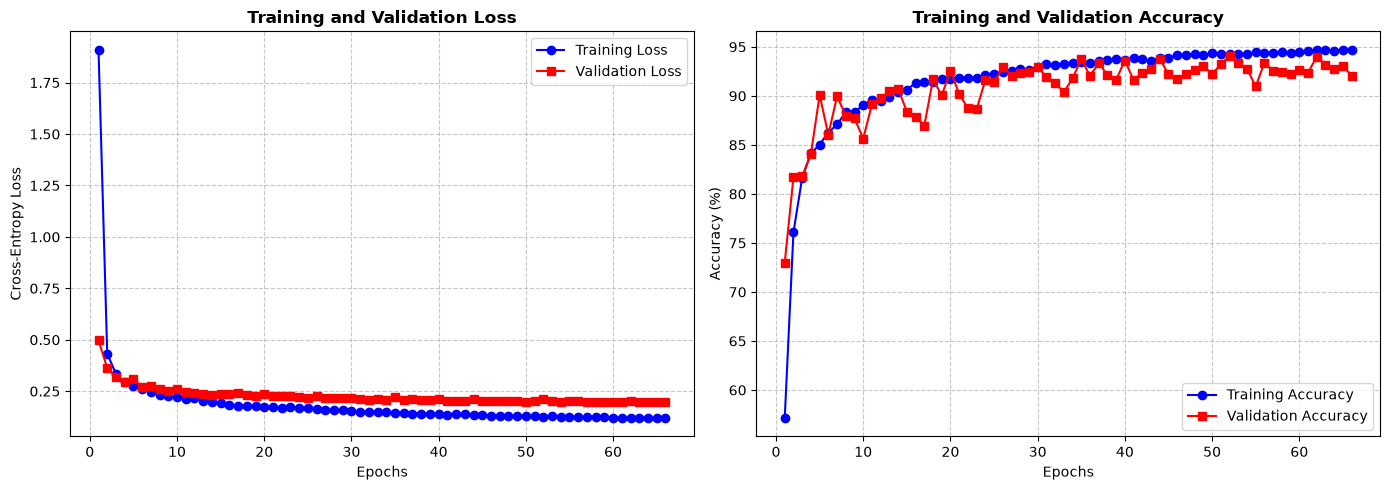

[EVAL] Saved learning curves figure to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/figures/learning_curves.png


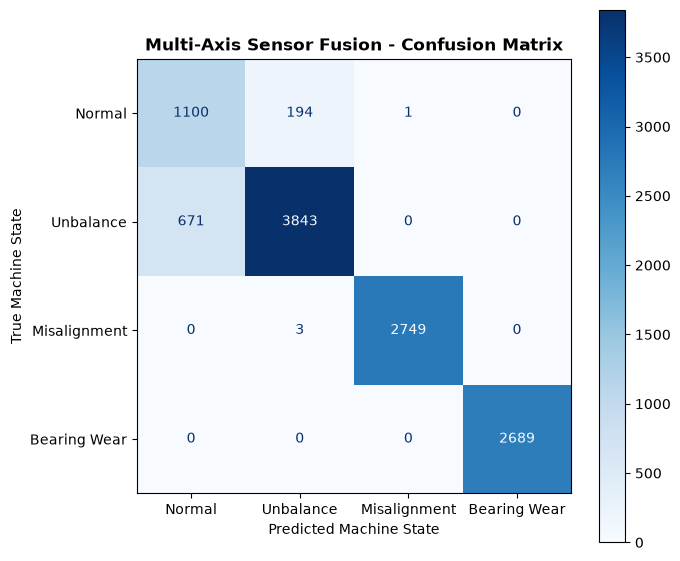

[EVAL] Saved confusion matrix figure to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/figures/confusion_matrix.png


In [17]:
# ============================================================================
# Cell 7: Model Evaluation & Performance Metrics
# ============================================================================

def plot_learning_curves(history, save_filename="learning_curves.png"):
    """Plots training and validation Loss and Accuracy progression over epochs."""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Subplot
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Training Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Validation Loss')
    axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Accuracy Subplot
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy')
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_filename, dpi=150)
    plt.show()
    print(f"[EVAL] Saved learning curves figure to {FIGURES_DIR / save_filename}")

def evaluate_and_plot_confusion(model, val_loader, save_filename="confusion_matrix.png"):
    """Generates confusion matrix for the validation dataset."""
    device = next(model.parameters()).device
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    plt.title("Multi-Axis Sensor Fusion - Confusion Matrix", fontsize=12, fontweight='bold')
    plt.xlabel("Predicted Machine State")
    plt.ylabel("True Machine State")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_filename, dpi=150)
    plt.show()
    print(f"[EVAL] Saved confusion matrix figure to {FIGURES_DIR / save_filename}")

# Generate evaluation charts
plot_learning_curves(train_history)
evaluate_and_plot_confusion(trained_model, val_loader)


### 8. Post-Training Quantization (PTQ) & Hardware Weight Export
To deploy trained PyTorch weights onto the Q8.16 FPGA hardware datapath, floating-point parameter matrices are quantized into 24-bit signed integers and exported to an NPZ archive (`trained_weights_q8_16.npz`).


In [18]:
# ============================================================================
# Cell 8: Q8.16 Post-Training Weight Quantization Exporter
# ============================================================================

def export_q8_16_weights(model, export_path):
    """
    Converts Float32 PyTorch weights into 24-bit Q8.16 signed integer representations.
    Exported tensors: conv1_w, conv1_b, dense1_w, dense1_b.
    """
    print(f"[EXPORT] Quantizing trained PyTorch weights to Q8.16 fixed-point...")
    
    conv_w = model.conv1.weight.detach().cpu().numpy()
    conv_b = model.conv1.bias.detach().cpu().numpy()
    dense_w = model.dense1.weight.detach().cpu().numpy()
    dense_b = model.dense1.bias.detach().cpu().numpy()
    
    def to_q8_16(val):
        scaled = np.round(val * SCALE_FACTOR)
        return np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

    q8_conv_w = to_q8_16(conv_w)
    q8_conv_b = to_q8_16(conv_b)
    q8_dense_w = to_q8_16(dense_w)
    q8_dense_b = to_q8_16(dense_b)
    
    np.savez(export_path, 
             conv1_w=q8_conv_w, conv1_b=q8_conv_b,
             dense1_w=q8_dense_w, dense1_b=q8_dense_b)
             
    print(f"[EXPORT] Successfully saved Q8.16 integer weights to {export_path}")
    print(f"         conv1_w shape: {q8_conv_w.shape}, min/max: [{q8_conv_w.min()}, {q8_conv_w.max()}]")
    print(f"         dense1_w shape: {q8_dense_w.shape}, min/max: [{q8_dense_w.min()}, {q8_dense_w.max()}]")

# Save Float32 model state and export Q8.16 weights archive
pytorch_model_path = BASE_DIR / "smma_pytorch_model.pth"
q8_16_weights_path = BASE_DIR / "trained_weights_q8_16.npz"

torch.save(trained_model.state_dict(), pytorch_model_path)
export_q8_16_weights(trained_model, q8_16_weights_path)


[EXPORT] Quantizing trained PyTorch weights to Q8.16 fixed-point...
[EXPORT] Successfully saved Q8.16 integer weights to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/trained_weights_q8_16.npz
         conv1_w shape: (8, 4, 3, 3), min/max: [-14001, 15688]
         dense1_w shape: (4, 2048), min/max: [-15357, 17628]


### 9. Bit-True Golden Model Hardware Simulation
The **Bit-True Golden Model** is a pure NumPy execution framework designed to simulate exact FPGA hardware behavior down to the bit-level without relying on PyTorch or deep learning frameworks.

#### Hardware Bit-True Arithmetic Features:
1. **24-bit Saturating Addition (`q8_16_add`)**: Adds two Q8.16 integers and clamps results to $[-8388608, 8388607]$.
2. **24x24-bit Multiplication (`q8_16_mul`)**: Multiplies two 24-bit integers yielding a 48-bit intermediate product, arithmetic right-shifts by 16 bits (`>> 16`) to truncate fractional expansion, and saturates to 24 bits.
3. **Hardware Conv2D Layer (`Conv2D_Q8_16`)**: Simulates FPGA line-buffer sliding windows and parallel Multiply-Accumulate (MAC) trees.
4. **Hardware ReLU (`ReLU_Q8_16`)**: Inspects Most Significant Bit (MSB sign bit) to zero out negative values.
5. **Hardware MaxPool2D (`Pooling_Q8_16`)**: Implements $2 \times 2$ comparator trees across feature maps.
6. **Hardware Dense Layer (`Dense_Q8_16`)**: Executes matrix-vector MAC accumulation with Q8.16 truncation.


In [19]:
# ============================================================================
# Cell 9: Bit-True Fixed-Point Golden Model Inference Simulation
# ============================================================================

def float_to_q8_16(val):
    scaled = np.round(val * SCALE_FACTOR)
    return np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

def q8_16_to_float(val):
    return val / float(SCALE_FACTOR)

def q8_16_add(a, b):
    res = a + b
    return np.clip(res, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

def q8_16_mul(a, b):
    # Simulates 24x24 multiplication with 48-bit intermediate product and 16-bit right-shift truncation
    prod = a.astype(np.int64) * b.astype(np.int64)
    truncated = prod >> FRACTIONAL_BITS
    return np.clip(truncated, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)


class Conv2D_Q8_16:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.weights = np.zeros((out_channels, in_channels, kernel_size, kernel_size), dtype=np.int64)
        self.biases = np.zeros((out_channels,), dtype=np.int64)
        
    def set_weights(self, w_q8, b_q8):
        self.weights = w_q8
        self.biases = b_q8

    def forward(self, x):
        h_in, w_in, c_in = x.shape
        h_out = (h_in + 2 * self.padding - self.kernel_size) // self.stride + 1
        w_out = (w_in + 2 * self.padding - self.kernel_size) // self.stride + 1
        
        if self.padding > 0:
            x_pad = np.pad(x, ((self.padding, self.padding), (self.padding, self.padding), (0, 0)),
                           mode='constant', constant_values=0)
        else:
            x_pad = x
            
        out = np.zeros((h_out, w_out, self.out_channels), dtype=np.int64)
        
        for i in range(h_out):
            for j in range(w_out):
                y_start, x_start = i * self.stride, j * self.stride
                window = x_pad[y_start:y_start+self.kernel_size, x_start:x_start+self.kernel_size, :]
                
                for oc in range(self.out_channels):
                    acc = self.biases[oc]
                    for ic in range(self.in_channels):
                        for kh in range(self.kernel_size):
                            for kw in range(self.kernel_size):
                                pixel = window[kh, kw, ic]
                                weight = self.weights[oc, ic, kh, kw]
                                prod = q8_16_mul(pixel, weight)
                                acc = q8_16_add(acc, prod)
                    out[i, j, oc] = acc
        return out


class ReLU_Q8_16:
    def forward(self, x):
        return np.maximum(x, 0)


class Pooling_Q8_16:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, x):
        h_in, w_in, c_in = x.shape
        h_out = (h_in - self.pool_size) // self.stride + 1
        w_out = (w_in - self.pool_size) // self.stride + 1
        out = np.zeros((h_out, w_out, c_in), dtype=np.int64)
        
        for i in range(h_out):
            for j in range(w_out):
                y_start, x_start = i * self.stride, j * self.stride
                window = x[y_start:y_start+self.pool_size, x_start:x_start+self.pool_size, :]
                out[i, j, :] = np.max(window, axis=(0, 1))
        return out


class Dense_Q8_16:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features
        self.weights = np.zeros((out_features, in_features), dtype=np.int64)
        self.biases = np.zeros((out_features,), dtype=np.int64)
        
    def set_weights(self, w_q8, b_q8):
        self.weights = w_q8
        self.biases = b_q8

    def forward(self, x):
        out = np.zeros(self.out_features, dtype=np.int64)
        for oc in range(self.out_features):
            acc = self.biases[oc]
            for ic in range(self.in_features):
                prod = q8_16_mul(x[ic], self.weights[oc, ic])
                acc = q8_16_add(acc, prod)
            out[oc] = acc
        return out


class SMMA_CNN_Q8_16_GoldenModel:
    """Full Bit-True Golden Model Pipeline."""
    def __init__(self):
        self.conv1 = Conv2D_Q8_16(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = ReLU_Q8_16()
        self.pool1 = Pooling_Q8_16(pool_size=2, stride=2)
        self.dense1 = Dense_Q8_16(in_features=2048, out_features=NUM_CLASSES)

    def load_weights(self, npz_path):
        data = np.load(npz_path)
        self.conv1.set_weights(data['conv1_w'], data['conv1_b'])
        self.dense1.set_weights(data['dense1_w'], data['dense1_b'])

    def forward(self, x):
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)
        x = x.flatten()
        x = self.dense1.forward(x)
        return x


# ============================================================================
# End-to-End Bit-True Inference Simulation
# ============================================================================
print("==========================================================")
print("  SMMA - Bit-True Golden Model End-to-End Inference Run  ")
print("==========================================================")

# 1. Synthesize 4-Channel raw vibration signals (Unbalance state: 30Hz + 60Hz)
t_vec = np.linspace(0, 1.0, 2048, endpoint=False)
base_sig = 1.5 * np.sin(2 * np.pi * 30 * t_vec) + 0.4 * np.sin(2 * np.pi * 60 * t_vec)

# Simulate 4 physical sensors (Housing A & B, X & Y) with independent noise
sig_xA = base_sig + 0.1 * np.random.randn(2048)
sig_yA = base_sig + 0.1 * np.random.randn(2048)
sig_xB = base_sig + 0.1 * np.random.randn(2048)
sig_yB = base_sig + 0.1 * np.random.randn(2048)

# 2. Front-End Preprocessing & Q8.16 Quantization for all channels
preprocessor = Preprocessor_Q8_16(frame_size=64, num_frames=32, use_lms=True)
spec_xA = preprocessor.process(sig_xA)
spec_yA = preprocessor.process(sig_yA)
spec_xB = preprocessor.process(sig_xB)
spec_yB = preprocessor.process(sig_yB)

# Concatenate to form the exact (32, 32, 4) input tensor expected by the CNN
spectrogram_q8_16 = np.concatenate((spec_xA, spec_yA, spec_xB, spec_yB), axis=2)

# 3. Instantiate Golden Model and Load Exported Q8.16 Weights
golden_model = SMMA_CNN_Q8_16_GoldenModel()
golden_model.load_weights(q8_16_weights_path)

# 4. Perform Bit-True Forward Pass
raw_q8_logits = golden_model.forward(spectrogram_q8_16)

# 5. Decode Logits and Predict Machine State
float_logits = [q8_16_to_float(v) for v in raw_q8_logits]
predicted_class_idx = int(np.argmax(raw_q8_logits))
predicted_state_name = CLASS_NAMES[predicted_class_idx]

print("\n[GOLDEN MODEL OUTPUTS]")
print(f"Raw Q8.16 Integer Logits : {raw_q8_logits}")
print("Decoded Float Logits     :")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    print(f"  - {cls_name:<15}: {float_logits[cls_idx]:8.4f}")

print("----------------------------------------------------------")
print(f"Predicted Machine State  : {predicted_state_name.upper()}")
print("==========================================================")


  SMMA - Bit-True Golden Model End-to-End Inference Run  

[GOLDEN MODEL OUTPUTS]
Raw Q8.16 Integer Logits : [-301274 -330079  463883  792584]
Decoded Float Logits     :
  - Normal         :  -4.5971
  - Unbalance      :  -5.0366
  - Misalignment   :   7.0783
  - Bearing Wear   :  12.0939
----------------------------------------------------------
Predicted Machine State  : BEARING WEAR


In [20]:
# ============================================================================
# Exporting Golden Model Input to SystemVerilog Testbench
# ============================================================================

def export_spectrogram_for_tb(spectrogram, filename):
    print(f"\n[TB EXPORT] Exporting Q8.16 Spectrogram to {filename}...")
    
    # Flatten the (32, 32, 1) array into a 1D array of 1024 elements
    flat_spec = spectrogram.flatten()
    
    with open(filename, 'w') as f:
        for val in flat_spec:
            # Convert to 24-bit two's complement hex
            val_int = int(val)
            if val_int < 0:
                val_int = (1 << 24) + val_int
            
            # Format as 6-digit uppercase hex
            hex_val = f"{val_int:06X}"
            f.write(f"{hex_val}\n")
            
    print(f"[SUCCESS] Exported {len(flat_spec)} pixels for RTL simulation.")

# Execute the export function
export_spectrogram_for_tb(spectrogram_q8_16, "cnn_tb_input.mem")


[TB EXPORT] Exporting Q8.16 Spectrogram to cnn_tb_input.mem...
[SUCCESS] Exported 4096 pixels for RTL simulation.


In [21]:
import numpy as np
from pathlib import Path

# ============================================================================
# Quartus Hexadecimal ROM Exporter (24-bit Q8.16)
# ============================================================================

def convert_to_24bit_hex(val):
    """
    Converts a signed integer to a 24-bit two's complement hexadecimal string.
    """
    val_int = int(val)
    if val_int < 0:
        val_int = (1 << 24) + val_int
    return f"{val_int:06X}"

def export_mem_files(npz_path, output_dir):
    print(f"[EXPORT] Loading Q8.16 weights from {npz_path}")
    data = np.load(npz_path)
    
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Export Dense Layer Weights
    # Shape expected: (OUT_CLASSES, IN_FEATURES) -> (4, 2048)
    dense_w = data['dense1_w']
    dense_w_file = out_dir / "dense_weights.mem"
    
    with open(dense_w_file, 'w') as f:
        for c in range(dense_w.shape[0]):
            for i in range(dense_w.shape[1]):
                hex_val = convert_to_24bit_hex(dense_w[c, i])
                f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Dense weights written to {dense_w_file}")
    
    # 2. Export Dense Layer Biases
    dense_b = data['dense1_b']
    dense_b_file = out_dir / "dense_biases.mem"
    
    with open(dense_b_file, 'w') as f:
        for c in range(dense_b.shape[0]):
            hex_val = convert_to_24bit_hex(dense_b[c])
            f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Dense biases written to {dense_b_file}")

    # 3. Export Conv2D Layer Weights (The Kernels)
    # Shape expected from PyTorch: (OUT_CHANNELS, IN_CHANNELS, K_H, K_W) -> (8, 4, 3, 3)
    conv_w = data['conv1_w']
    conv_w_file = out_dir / "conv2d_weights.mem"

    with open(conv_w_file, 'w') as f:
        for oc in range(conv_w.shape[0]):
            for ic in range(conv_w.shape[1]):
                for h in range(conv_w.shape[2]):
                    for w in range(conv_w.shape[3]):
                        hex_val = convert_to_24bit_hex(conv_w[oc, ic, h, w])
                        f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Conv2D weights (kernels) written to {conv_w_file}")

    # 4. Export Conv2D Layer Biases
    conv_b = data['conv1_b']
    conv_b_file = out_dir / "conv2d_biases.mem"

    with open(conv_b_file, 'w') as f:
        for oc in range(conv_b.shape[0]):
            hex_val = convert_to_24bit_hex(conv_b[oc])
            f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Conv2D biases written to {conv_b_file}")

    # (Optional) Export Conv2D weights here following the same structure

# Execute the extraction
npz_file = "trained_weights_q8_16.npz" # Update path if needed
export_mem_files(npz_file, "./rtl/")

[EXPORT] Loading Q8.16 weights from trained_weights_q8_16.npz
[SUCCESS] Dense weights written to rtl/dense_weights.mem
[SUCCESS] Dense biases written to rtl/dense_biases.mem
[SUCCESS] Conv2D weights (kernels) written to rtl/conv2d_weights.mem
[SUCCESS] Conv2D biases written to rtl/conv2d_biases.mem
